# S² Visualization: Base, Target, RCPM, and Ours

Visualizes distributions on the sphere S² similar to Figure 5 style.

In [1]:
import sys
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['HIP_VISIBLE_DEVICES'] = '6'
%load_ext autoreload
%autoreload 2
sys.path.insert(0, 'rcpm')

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
from jax import random

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde
import optax

# RCPM imports
import flows as rcpm_flows
import manifolds as rcpm_manifolds

# Our method imports
from src.base import ExperimentConfig
from src.manifolds import get as get_manifold
import src.densities as densities
from src.embeddings import GromovDistanceEmbedding, build_landmarks
from src.networks import build_network
from src.solvers import ArgminSolver
from src.losses import SemiDualLoss
from src.trainers import SemiDualTrainer
from src.metrics import (
    compute_kl_divergence, 
    compute_kl_divergence_autodiff,
    compute_ess,
)
import src.utils as utils

print(f"Running on: {jax.devices()}")

Running on: [RocmDevice(id=0)]


In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================
N_SAMPLES = 5000        # samples to visualize
SEED = 12345
RCPM_GAMMA = 1.0
RCPM_N_ITERS = 5000     # RCPM training iterations

# Landmark selection method: "fps" or "random"
LANDMARK_METHOD = "fps"
FPS_CANDIDATES = 5000    # number of candidates for FPS selection

In [3]:
# =============================================================================
# SPHERE VISUALIZATION UTILITIES
# =============================================================================

def euclidean_to_spherical(xyz):
    """Convert (x,y,z) on S² to (theta, phi) spherical coords.
    theta: azimuthal angle in [-pi, pi]
    phi: polar angle (colatitude) in [0, pi]
    """
    x, y, z = xyz[..., 0], xyz[..., 1], xyz[..., 2]
    theta = np.arctan2(y, x)  # azimuthal
    phi = np.arccos(np.clip(z, -1, 1))  # polar (colatitude)
    return np.stack([theta, phi], axis=-1)


def spherical_to_euclidean(tp):
    """Convert (theta, phi) to (x,y,z) on S²."""
    theta, phi = tp[..., 0], tp[..., 1]
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    return np.stack([x, y, z], axis=-1)


def compute_density_on_sphere(samples_xyz, n_grid=100):
    """
    Estimate density on the sphere using KDE in spherical coordinates.
    Returns density grid for Mollweide projection.
    """
    # Convert to spherical
    samples_tp = euclidean_to_spherical(np.array(samples_xyz))
    
    # Create grid
    theta_grid = np.linspace(-np.pi, np.pi, 2 * n_grid)
    phi_grid = np.linspace(0, np.pi, n_grid)
    T, P = np.meshgrid(theta_grid, phi_grid)
    positions = np.vstack([T.ravel(), P.ravel()])
    
    # Periodic KDE in theta direction
    offsets = [-2*np.pi, 0, 2*np.pi]
    replicated = []
    for o in offsets:
        rep = samples_tp.copy()
        rep[:, 0] += o
        replicated.append(rep)
    replicated = np.vstack(replicated)
    
    try:
        kde = gaussian_kde(replicated.T, bw_method=0.2)
        density = kde(positions).reshape(T.shape)
    except:
        density = np.ones(T.shape)
    
    # Normalize
    density = (density - density.min()) / (density.max() - density.min() + 1e-8)
    return density, T, P, theta_grid, phi_grid

In [4]:
# =============================================================================
# RCPM DENSITY CLASSES
# =============================================================================
from dataclasses import dataclass
from jax.scipy.stats import norm

def get_rcpm_zero(manifold):
    if hasattr(manifold, 'zero'):
        return manifold.zero()
    raise ValueError(f"Cannot get zero for {type(manifold)}")


@dataclass
class RCPMSphereUniform:
    manifold: any
    
    def log_prob(self, xs):
        n_batch, D = xs.shape
        # Surface area of S^{D-1} = 2 * pi^{D/2} / Gamma(D/2)
        log_SA = jnp.log(2.0) + (D / 2.0) * jnp.log(jnp.pi) - jax.scipy.special.gammaln(D / 2.0)
        return jnp.full([n_batch], -log_SA)
    
    def sample(self, key, n_samples):
        xs = random.normal(key, shape=[n_samples, self.manifold.D])
        return self.manifold.projx(xs)
    
    def __hash__(self): return 0


@dataclass
class RCPMSphereWrappedNormal:
    manifold: any
    scale: float = 0.5
    
    def __post_init__(self):
        self.loc = get_rcpm_zero(self.manifold)
        self._scale = jnp.full(self.manifold.D - 1, self.scale)
    
    def log_prob(self, z):
        loc = jnp.broadcast_to(self.loc, z.shape)
        u = self.manifold.log(loc, z)
        y = self.manifold.zero_like(loc)
        v = self.manifold.transp(loc, y, u)
        v = self.manifold.squeeze_tangent(v)
        n_logprob = norm.logpdf(v, scale=self._scale).sum(axis=-1)
        logdet = self.manifold.logdetexp(loc, u)
        return n_logprob - logdet
    
    def sample(self, key, n_samples):
        v = self._scale * random.normal(key, [n_samples, self.manifold.D - 1])
        v = self.manifold.unsqueeze_tangent(v)
        loc = jnp.broadcast_to(self.loc, (n_samples, self.manifold.D))
        x = self.manifold.zero_like(loc)
        u = self.manifold.transp(x, loc, v)
        z = self.manifold.exponential_map(loc, u)
        return z
    
    def __hash__(self): return 0

In [5]:
# =============================================================================
# BUILD AND TRAIN OUR METHOD
# =============================================================================
def build_and_train_ours():
    """Build and train our semi-dual OT model on S2."""
    print("Building our method...")
    
    exp_cfg = ExperimentConfig(
        manifold_name="S2",
        base_density="SphereUniform",
        target_density="SphereWrappedNormal",
        jax_platform="gpu",
    )

    manifold = get_manifold(exp_cfg.manifold_name)
    base = densities.get(manifold, exp_cfg.base_density)
    target = densities.get(manifold, exp_cfg.target_density)

    key = jax.random.PRNGKey(SEED)
    
    # Landmark selection: FPS or random
    n_landmarks = exp_cfg.model.n_landmarks
    n_base = n_landmarks // 2
    n_target = n_landmarks - n_base
    
    if LANDMARK_METHOD == "fps":
        print(f"Using FPS landmark selection ({n_landmarks} landmarks from {FPS_CANDIDATES} candidates)...")
        landmark_cfg_base = {"n_landmarks": n_base, "method": "fps", "fps_candidates": FPS_CANDIDATES}
        landmark_cfg_target = {"n_landmarks": n_target, "method": "fps", "fps_candidates": FPS_CANDIDATES}
        landmarks_base, key = build_landmarks(manifold, base, landmark_cfg_base, key)
        landmarks_target, key = build_landmarks(manifold, target, landmark_cfg_target, key)
    else:
        print(f"Using random landmark selection ({n_landmarks} landmarks)...")
        key, k1, k2 = jax.random.split(key, 3)
        landmarks_base = base.sample(k1, n_base)
        landmarks_target = target.sample(k2, n_target)
    
    landmarks = jnp.concatenate([landmarks_base, landmarks_target], axis=0)
    
    emb = GromovDistanceEmbedding(manifold=manifold, landmarks=landmarks)
    psi = build_network(
        phi=emb,
        network_type=exp_cfg.model.network_type,
        hidden_dims=exp_cfg.model.hidden_dims,
        use_layernorm=exp_cfg.model.use_layernorm,
        last_scale=exp_cfg.model.last_scale,
        activation=exp_cfg.model.activation,
        leaky_slope=exp_cfg.model.leaky_slope,
        softplus_beta=exp_cfg.model.softplus_beta,
        max_dist=exp_cfg.model.max_dist,
    )

    key, kx_init, kparams = jax.random.split(key, 3)
    x_init = base.sample(kx_init, 16)
    psi_vars = psi.init(kparams, x_init)
    psi_params = psi_vars["params"]

    solver = ArgminSolver(
        manifold=manifold, psi_module=psi,
        inner_steps=exp_cfg.solver.inner_steps,
        inner_lr=exp_cfg.solver.inner_lr,
        grad_clip=exp_cfg.solver.grad_clip,
        lr_decay=exp_cfg.solver.lr_decay,
        tolerance=exp_cfg.solver.tolerance,
        min_steps=exp_cfg.solver.min_steps,
        momentum=exp_cfg.solver.momentum,
        logsumexp_init=exp_cfg.solver.logsumexp_init,
        logsumexp_gamma=exp_cfg.solver.logsumexp_gamma,
        use_adam=exp_cfg.solver.use_adam,
        adam_beta1=exp_cfg.solver.adam_beta1,
        adam_beta2=exp_cfg.solver.adam_beta2,
    )

    loss_obj = SemiDualLoss(manifold=manifold, psi_module=psi, solver=solver)
    trainer = SemiDualTrainer(
        manifold=manifold, psi_module=psi, loss_fn=loss_obj, solver=solver,
        learning_rate=exp_cfg.training.learning_rate,
        lr_decay=exp_cfg.training.lr_decay,
        lr_decay_alpha=exp_cfg.training.lr_decay_alpha,
        n_steps=exp_cfg.training.n_steps,
    )

    state = trainer.init_state(psi_params)
    
    print(f"Training our method for {exp_cfg.training.n_steps} iterations...")
    state, history = trainer.train(
        state=state,
        base_density=base,
        target_density=target,
        key=key,
        n_steps=exp_cfg.training.n_steps,
        batch_size=exp_cfg.training.batch_size,
        log_every=exp_cfg.training.log_every,
        eval_every=exp_cfg.training.eval_every,
        eval_size=exp_cfg.training.eval_size,
        callbacks=[],
    )
    
    return {
        'manifold': manifold,
        'base': base,
        'target': target,
        'solver': solver,
        'state': state,
        'psi': psi,
    }


ours_exp = build_and_train_ours()

Building our method...
Using FPS landmark selection (128 landmarks from 5000 candidates)...


/home/sjbhatt/anaconda3/envs/rcpms-jax/lib/python3.10/site-packages/jax/_src/ops/scatter.py:92: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/home/sjbhatt/anaconda3/envs/rcpms-jax/lib/python3.10/site-packages/jax/_src/ops/scatter.py:92: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Training our method for 200 iterations...
[     1] loss=0.1231 | res=2.31e-09 | grad=7.26e+00 | 9.5s
[     2] loss=-0.0270 | res=7.17e-05 | grad=6.34e+00 | 1.1s
[     3] loss=-0.1445 | res=3.11e-09 | grad=5.34e+00 | 1.1s
[     4] loss=-0.2733 | res=2.42e-04 | grad=5.43e+00 | 1.1s
[     5] loss=-0.3573 | res=2.76e-04 | grad=4.86e+00 | 1.1s
[     6] loss=-0.4639 | res=2.96e-09 | grad=4.72e+00 | 1.1s
[     7] loss=-0.5834 | res=8.87e-05 | grad=4.83e+00 | 1.1s
[     8] loss=-0.5970 | res=5.93e-05 | grad=3.26e+00 | 1.1s
[     9] loss=-0.6645 | res=2.38e-04 | grad=2.84e+00 | 1.1s
[    10] loss=-0.6810 | res=2.06e-04 | grad=1.98e+00 | 1.1s
[    11] loss=-0.8279 | res=4.26e-04 | grad=1.70e+00 | 1.1s
[    12] loss=-0.7360 | res=1.80e-04 | grad=7.22e-01 | 1.1s
[    13] loss=-0.8316 | res=3.93e-04 | grad=9.89e-01 | 1.1s
[    14] loss=-0.8402 | res=1.44e-04 | grad=6.36e-01 | 1.1s
[    15] loss=-0.8541 | res=2.30e-04 | grad=6.86e-01 | 1.1s
[    16] loss=-0.8897 | res=1.65e-04 | grad=5.13e-01 | 1.1s

In [6]:
# =============================================================================
# BUILD AND TRAIN RCPM
# =============================================================================
def build_and_train_rcpm(n_iters=500, gamma=0.1, log_every=50):
    """Build and train RCPM flow model on S2."""
    print("Building RCPM...")
    
    manifold = rcpm_manifolds.Sphere(D=3)  # S2 embedded in R3
    base = RCPMSphereUniform(manifold=manifold)
    target = RCPMSphereWrappedNormal(manifold=manifold, scale=0.5)
    
    potential_cfg = {
        '_target_': 'flows.InfAffine',
        'n_components': 68,
        'init_alpha_mode': 'uniform',
        'init_alpha_linear_scale': 1.0,
        'init_alpha_minval': 0.4,
        'init_alpha_range': 0.01,
        'cost_gamma': gamma,
        'min_zero_gamma': None,
    }
    
    single_transform_cfg = {
        '_target_': 'flows.ExpMapFlow',
        'potential_cfg': potential_cfg,
    }
    
    flow = rcpm_flows.SequentialFlow(
        n_transforms=5,
        manifold=manifold,
        single_transform_cfg=single_transform_cfg,
    )
    
    key = jax.random.PRNGKey(SEED)
    key, k1, k2 = jax.random.split(key, 3)
    batch = base.sample(k1, 16)
    params = flow.init(k2, batch)
    
    optimizer = optax.adam(1e-3)
    opt_state = optimizer.init(params)
    
    @jax.jit
    def loss_fn(params, base_samples, base_log_probs):
        z, ldjs = flow.apply(params, base_samples)
        return (base_log_probs - ldjs - target.log_prob(z)).mean()
    
    @jax.jit
    def update(params, opt_state, base_samples, base_log_probs):
        loss, grads = jax.value_and_grad(loss_fn)(params, base_samples, base_log_probs)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return loss, params, opt_state
    
    print(f"Training RCPM for {n_iters} iterations (log_every={log_every})...")
    for i in range(n_iters):
        key, subkey = jax.random.split(key)
        base_samples = base.sample(subkey, 128)
        base_log_probs = base.log_prob(base_samples)
        loss, params, opt_state = update(params, opt_state, base_samples, base_log_probs)
        if (i + 1) % log_every == 0:
            print(f"  [{i+1:5d}] loss = {loss:.4f}")
    
    return {
        'manifold': manifold,
        'base': base,
        'target': target,
        'flow': flow,
        'params': params,
        'key': key,
    }


rcpm_exp = build_and_train_rcpm(n_iters=RCPM_N_ITERS, gamma=RCPM_GAMMA, log_every=100)

Building RCPM...
Training RCPM for 5000 iterations (log_every=100)...
  [  100] loss = 1.4696
  [  200] loss = 0.3708
  [  300] loss = 0.1428
  [  400] loss = 0.0186
  [  500] loss = 0.0373
  [  600] loss = -0.0129
  [  700] loss = 0.0031
  [  800] loss = 0.0938
  [  900] loss = 0.0663
  [ 1000] loss = 0.0146
  [ 1100] loss = 0.0482
  [ 1200] loss = -0.0063
  [ 1300] loss = -0.0100
  [ 1400] loss = 0.0230
  [ 1500] loss = -0.0017
  [ 1600] loss = 0.0110
  [ 1700] loss = 0.0799
  [ 1800] loss = -0.0160
  [ 1900] loss = -0.0092
  [ 2000] loss = 0.0196
  [ 2100] loss = 0.0110
  [ 2200] loss = 0.0039
  [ 2300] loss = -0.0015
  [ 2400] loss = 0.0209
  [ 2500] loss = 0.0575
  [ 2600] loss = -0.0031
  [ 2700] loss = 0.0155
  [ 2800] loss = 0.0049
  [ 2900] loss = -0.0062
  [ 3000] loss = -0.0034
  [ 3100] loss = 0.0083
  [ 3200] loss = 0.0023
  [ 3300] loss = 0.0083
  [ 3400] loss = -0.0014
  [ 3500] loss = 0.0053
  [ 3600] loss = 0.0065
  [ 3700] loss = -0.0044
  [ 3800] loss = 0.0016
  [ 39

In [7]:
# =============================================================================
# CONVERGENCE ANALYSIS
# =============================================================================
key = jax.random.PRNGKey(42)
k1, k2 = jax.random.split(key)
n_test = 512

xs = ours_exp['base'].sample(k1, n_test)
y_samples = ours_exp['target'].sample(k2, n_test)

# Run convergence analysis
analysis = ours_exp['solver'].analyze_convergence(
    psi_params=ours_exp['state'].params,
    xs=xs,
    y_samples=y_samples,
    threshold=1e-2,
)

ours_exp['solver'].print_convergence_report(analysis)

CONVERGENCE ANALYSIS
Solver: Adam, steps=2500, lr=0.05, tol=1e-06

Residual Statistics (N=512):
  Min:    7.33e-17
  Median: 1.25e-15
  Mean:   9.04e-05
  P90:    2.89e-15
  P99:    6.42e-15
  Max:    1.97e-02

Convergence: 99.4% (509/512)

Failing samples (3):
  [  23] res=1.22e-02, init_dist=0.655, final_dist=0.641
  [  55] res=1.97e-02, init_dist=0.028, final_dist=0.037
  [ 282] res=1.44e-02, init_dist=0.625, final_dist=0.611

Init distance comparison:
  Passing samples: mean=1.281
  Failing samples: mean=0.436


In [8]:
# =============================================================================
# GENERATE SAMPLES
# =============================================================================
print("Generating samples...")

key = jax.random.PRNGKey(123)
k1, k2, k3, k4 = jax.random.split(key, 4)

# Base samples (uniform)
base_samples_ours = ours_exp['base'].sample(k1, N_SAMPLES)

# Target samples
target_samples_ours = ours_exp['target'].sample(k2, N_SAMPLES)

# Our method: transport base to target
ours_transported, _ = ours_exp['solver'].batch_solve(
    ours_exp['state'].params, base_samples_ours, target_samples_ours
)

# RCPM: transform base to target
base_samples_rcpm = rcpm_exp['base'].sample(k3, N_SAMPLES)
rcpm_transported, _ = rcpm_exp['flow'].apply(rcpm_exp['params'], base_samples_rcpm)

print(f"Base samples shape: {base_samples_ours.shape}")
print(f"Target samples shape: {target_samples_ours.shape}")
print(f"Ours transported shape: {ours_transported.shape}")
print(f"RCPM transported shape: {rcpm_transported.shape}")

Generating samples...


2026-01-26 14:32:34.059599: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce.94 = f64[5000,128]{1,0} reduce(f64[5000,128,3]{2,1,0} %broadcast.344, f64[] %constant.168), dimensions={2}, to_apply=%region_5.74, metadata={op_name="jit(solve_one)/jit(main)/vmap(while)/body/jvp(MLP)/phi/vmap(vmap(jit(norm)))/reduce_sum" source_file="/home/sjbhatt/riemannian-neural-ot/src/manifolds.py" source_line=189}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-01-26 14:32:34.991522: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.93208347s
Constant folding an 

Base samples shape: (5000, 3)
Target samples shape: (5000, 3)
Ours transported shape: (5000, 3)
RCPM transported shape: (5000, 3)


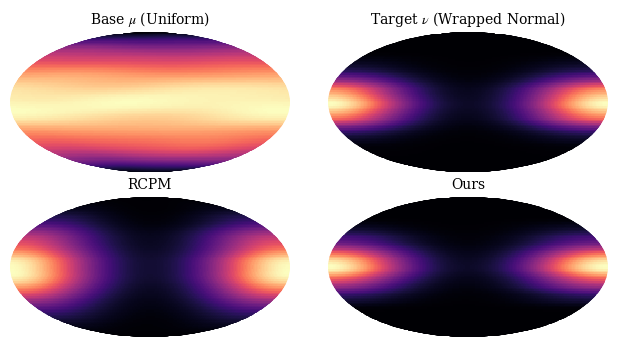

Saved: sphere_mollweide_comparison.png/pdf


In [9]:
# =============================================================================
# MOLLWEIDE PROJECTION VISUALIZATION
# =============================================================================
import matplotlib

# ICML-style plot settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})


def plot_mollweide(ax, samples_xyz, title, cmap='magma'):
    """
    Plot samples on sphere using Mollweide projection.
    samples_xyz: (N, 3) array of points on S2
    """
    # Convert to spherical
    samples_tp = euclidean_to_spherical(np.array(samples_xyz))
    
    # Mollweide uses longitude in [-pi, pi] and latitude in [-pi/2, pi/2]
    lon = samples_tp[:, 0]  # theta (azimuthal) already in [-pi, pi]
    lat = np.pi/2 - samples_tp[:, 1]  # convert colatitude to latitude
    
    # Compute density
    density, T, P, theta_grid, phi_grid = compute_density_on_sphere(samples_xyz, n_grid=100)
    
    # Convert grid to Mollweide coords
    lon_grid = theta_grid  # already [-pi, pi]
    lat_grid = np.pi/2 - phi_grid  # colatitude to latitude
    Lon, Lat = np.meshgrid(lon_grid, lat_grid)
    
    # Plot heatmap
    norm = matplotlib.colors.Normalize()
    im = ax.pcolormesh(Lon, Lat, density, cmap=cmap, norm=norm, shading='auto')
    
    ax.set_title(title)
    ax.set_axis_off()
    
    return im


fig = plt.figure(figsize=(6.5, 3.5))

ax1 = fig.add_subplot(2, 2, 1, projection='mollweide')
ax2 = fig.add_subplot(2, 2, 2, projection='mollweide')
ax3 = fig.add_subplot(2, 2, 3, projection='mollweide')
ax4 = fig.add_subplot(2, 2, 4, projection='mollweide')

plot_mollweide(ax1, base_samples_ours, r'Base $\mu$ (Uniform)')
plot_mollweide(ax2, target_samples_ours, r'Target $\nu$ (Wrapped Normal)')
plot_mollweide(ax3, rcpm_transported, 'RCPM')
plot_mollweide(ax4, ours_transported, 'Ours')

plt.tight_layout()
plt.savefig('sphere_mollweide_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('sphere_mollweide_comparison.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: sphere_mollweide_comparison.png/pdf")

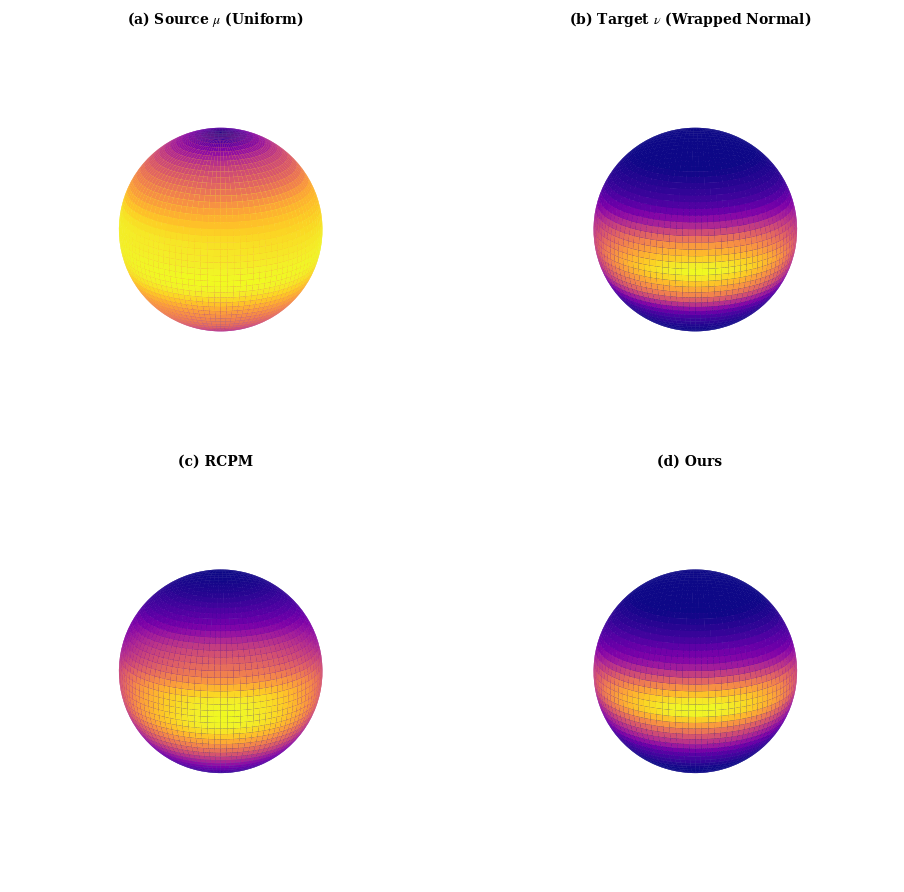

Saved: sphere_3d_comparison.png/pdf


In [10]:
# =============================================================================
# 3D SPHERE VISUALIZATION
# =============================================================================

def create_sphere_surface(n_points=50):
    """Create 3D sphere mesh for surface plotting."""
    theta = np.linspace(-np.pi, np.pi, 2 * n_points)
    phi = np.linspace(0, np.pi, n_points)
    T, P = np.meshgrid(theta, phi)
    
    x = np.sin(P) * np.cos(T)
    y = np.sin(P) * np.sin(T)
    z = np.cos(P)
    return x, y, z, T, P


def plot_3d_sphere_density(ax, samples_xyz, title, cmap='plasma'):
    """
    Plot density on 3D sphere surface.
    samples_xyz: (N, 3) array of points on S2
    """
    from scipy.interpolate import RegularGridInterpolator
    
    # Create sphere surface mesh
    n_points = 50
    x_surf, y_surf, z_surf, T, P = create_sphere_surface(n_points)
    
    # Compute density on a grid
    density, _, _, theta_grid, phi_grid = compute_density_on_sphere(samples_xyz, n_grid=100)
    
    # Interpolate density to surface mesh
    interp = RegularGridInterpolator((phi_grid, theta_grid), density,
                                      bounds_error=False, fill_value=0)
    
    # Map surface mesh (theta, phi) to density
    points = np.stack([P.ravel(), T.ravel()], axis=1)
    # Wrap theta to [-pi, pi]
    points[:, 1] = np.mod(points[:, 1] + np.pi, 2*np.pi) - np.pi
    density_surf = interp(points).reshape(T.shape)
    
    # Map density to colors
    norm = plt.Normalize(vmin=density_surf.min(), vmax=density_surf.max())
    colors = plt.colormaps.get_cmap(cmap)(norm(density_surf))
    
    # Plot surface
    ax.plot_surface(x_surf, y_surf, z_surf, facecolors=colors,
                    rstride=1, cstride=1, linewidth=0, antialiased=True, shade=False)
    
    ax.set_title(title, fontsize=10, fontweight='bold', pad=5)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_zlim(-1.2, 1.2)
    ax.set_axis_off()
    ax.set_box_aspect([1, 1, 1])
    
    return ax


fig = plt.figure(figsize=(10, 9))

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax4 = fig.add_subplot(2, 2, 4, projection='3d')

cmap = 'plasma'

plot_3d_sphere_density(ax1, base_samples_ours, r'(a) Source $\mu$ (Uniform)', cmap=cmap)
plot_3d_sphere_density(ax2, target_samples_ours, r'(b) Target $\nu$ (Wrapped Normal)', cmap=cmap)
plot_3d_sphere_density(ax3, rcpm_transported, '(c) RCPM', cmap=cmap)
plot_3d_sphere_density(ax4, ours_transported, '(d) Ours', cmap=cmap)

# Set viewing angle
for ax in [ax1, ax2, ax3, ax4]:
    ax.view_init(elev=20, azim=180)

plt.tight_layout()
plt.savefig('sphere_3d_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('sphere_3d_comparison.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: sphere_3d_comparison.png/pdf")

In [11]:
# =============================================================================
# KL DIVERGENCE COMPARISON
# =============================================================================
import time

print("="*60)
print("KL DIVERGENCE COMPARISON")
print("="*60)
print("\nKL(T#mu || nu) = E[log mu(x) - log nu(T(x)) - log|det J_T(x)|]")

# Use fewer samples for KL computation
n_kl = 1024
key_kl = jax.random.PRNGKey(13345)  # Same as table: 12345 + 1000

xs_kl = ours_exp['base'].sample(key_kl, n_kl)
ys_target = ours_exp['target'].sample(key_kl, n_kl)

# Transport samples
ys_kl, residuals = ours_exp['solver'].batch_solve(
    ours_exp['state'].params, xs_kl, target_samples_ours[:n_kl]
)
print(f"\nOurs solver residual: {float(jnp.mean(residuals)):.2e}")

# -----------------------------------------------------------------------------
# Method 1: Ours via IFT
# -----------------------------------------------------------------------------
print("\n[1] Ours (IFT)...")
t0 = time.time()
kl_ift = compute_kl_divergence(
    psi_params=ours_exp['state'].params,
    xs=xs_kl,
    ys=ys_kl,
    base_density=ours_exp['base'],
    target_density=ours_exp['target'],
    manifold=ours_exp['manifold'],
    psi_module=ours_exp['psi'],
)
t_ift = time.time() - t0
print(f"    Time: {t_ift:.2f}s")

# -----------------------------------------------------------------------------
# Method 2: Ours via Autodiff
# -----------------------------------------------------------------------------
print("\n[2] Ours (Autodiff)...")
t0 = time.time()
kl_autodiff = compute_kl_divergence_autodiff(
    psi_params=ours_exp['state'].params,
    xs=xs_kl,
    base_density=ours_exp['base'],
    target_density=ours_exp['target'],
    solver=ours_exp['solver'],
    manifold=ours_exp['manifold'],
    y_samples=target_samples_ours,
)
t_autodiff = time.time() - t0
print(f"    Time: {t_autodiff:.2f}s")

# -----------------------------------------------------------------------------
# Method 3: RCPM
# -----------------------------------------------------------------------------
print("\n[3] RCPM...")
t0 = time.time()

key_rcpm = jax.random.PRNGKey(778)
rcpm_xs = rcpm_exp['base'].sample(key_rcpm, n_kl)
rcpm_ys, rcpm_ldjs = rcpm_exp['flow'].apply(rcpm_exp['params'], rcpm_xs)

rcpm_log_mu = rcpm_exp['base'].log_prob(rcpm_xs)
rcpm_log_nu = rcpm_exp['target'].log_prob(rcpm_ys)

rcpm_kl_per_sample = rcpm_log_mu - rcpm_ldjs - rcpm_log_nu
rcpm_kl = float(jnp.mean(rcpm_kl_per_sample))

rcpm_log_weights = -rcpm_kl_per_sample
rcpm_ess, rcpm_ess_ratio = compute_ess(rcpm_log_weights)

t_rcpm = time.time() - t0
print(f"    Time: {t_rcpm:.2f}s")

# -----------------------------------------------------------------------------
# Comparison Table
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print(f"RESULTS (N={n_kl} samples)")
print("="*60)
print(f"{'Method':<25} {'KL':>12} {'ESS ratio':>12} {'Time (s)':>10}")
print("-"*60)
print(f"{'Ours (IFT)':<25} {kl_ift.kl:>12.4f} {kl_ift.ess_ratio*100:>11.1f}% {t_ift:>10.2f}")
print(f"{'Ours (Autodiff)':<25} {kl_autodiff.kl:>12.4f} {kl_autodiff.ess_ratio*100:>11.1f}% {t_autodiff:>10.2f}")
print(f"{'RCPM':<25} {rcpm_kl:>12.4f} {rcpm_ess_ratio*100:>11.1f}% {t_rcpm:>10.2f}")
print("-"*60)

KL DIVERGENCE COMPARISON

KL(T#mu || nu) = E[log mu(x) - log nu(T(x)) - log|det J_T(x)|]

Ours solver residual: 1.82e-04

[1] Ours (IFT)...
    Time: 37.50s

[2] Ours (Autodiff)...
    Time: 23.04s

[3] RCPM...
    Time: 13.70s

RESULTS (N=1024 samples)
Method                              KL    ESS ratio   Time (s)
------------------------------------------------------------
Ours (IFT)                      0.0574        94.8%      37.50
Ours (Autodiff)                -0.2218         0.1%      23.04
RCPM                           -0.0008        99.6%      13.70
------------------------------------------------------------


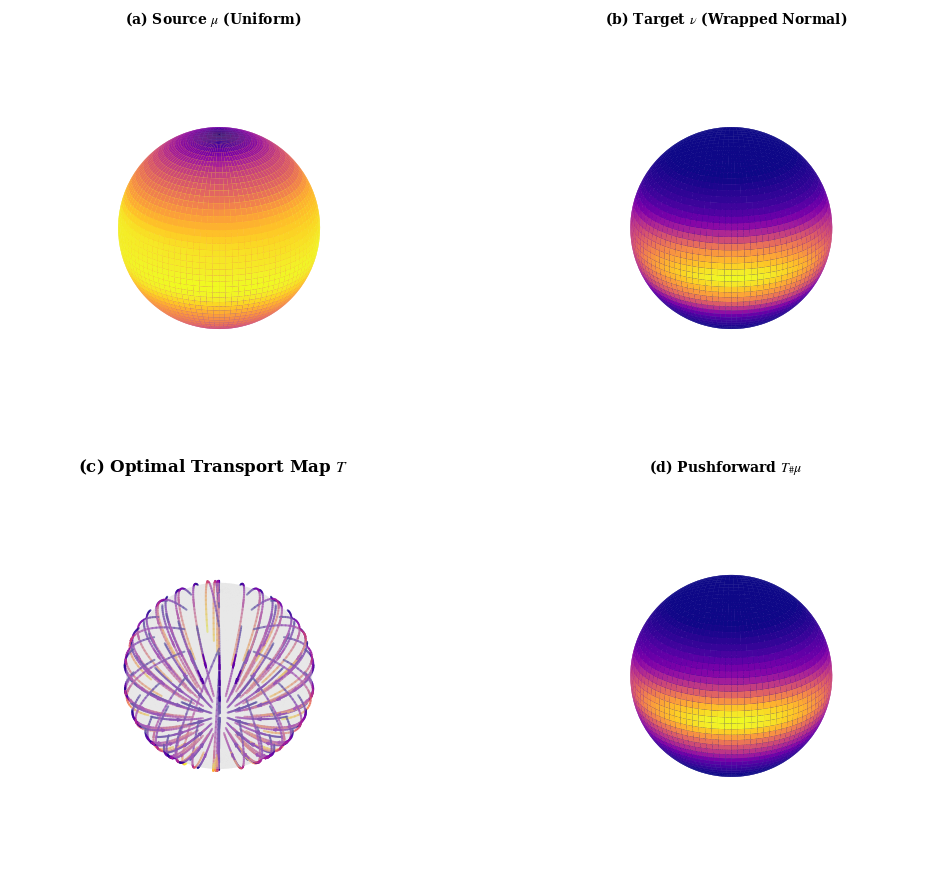


Drawn 128 flow lines with direction arrows
Saved: sphere_ot_figure.png


In [12]:
# =============================================================================
# 3D SPHERE WITH FLOW LINES
# =============================================================================

def plot_3d_sphere_with_flows(ax, title, solver, state_params, manifold, target_samples,
                               flow_cmap='plasma', n_lat=8, n_lon=16,
                               line_width=1.0, line_alpha=0.8,
                               surface_alpha=0.3, show_arrows=True, arrow_scale=0.15):
    """
    Plot 3D sphere with flow lines from latitude/longitude grid.
    """
    # Create semi-transparent sphere surface
    n_points = 30
    theta = np.linspace(-np.pi, np.pi, 2 * n_points)
    phi = np.linspace(0, np.pi, n_points)
    T, P = np.meshgrid(theta, phi)
    
    x_surf = np.sin(P) * np.cos(T)
    y_surf = np.sin(P) * np.sin(T)
    z_surf = np.cos(P)
    
    # Light gray surface
    colors = np.ones((*T.shape, 4)) * 0.8
    colors[:, :, 3] = surface_alpha
    ax.plot_surface(x_surf, y_surf, z_surf, facecolors=colors,
                    rstride=1, cstride=1, linewidth=0, antialiased=True, 
                    shade=False, zorder=1)
    
    # Generate source points on lat/lon grid
    lat_vals = np.linspace(0.2*np.pi, 0.8*np.pi, n_lat)  # avoid poles
    lon_vals = np.linspace(-np.pi, np.pi, n_lon, endpoint=False)
    
    src_points = []
    for phi_val in lat_vals:
        for theta_val in lon_vals:
            x = np.sin(phi_val) * np.cos(theta_val)
            y = np.sin(phi_val) * np.sin(theta_val)
            z = np.cos(phi_val)
            src_points.append([x, y, z])
    
    src_points = jnp.array(src_points)
    
    # Transport points
    dst_points, _ = solver.batch_solve(state_params, src_points, target_samples[:len(src_points)])
    dst_points = np.array(dst_points)
    src_points = np.array(src_points)
    
    # Compute geodesic distances for coloring
    geodesic_dists = []
    for i in range(len(src_points)):
        dot = np.clip(np.dot(src_points[i], dst_points[i]), -1, 1)
        dist = np.arccos(dot)
        geodesic_dists.append(dist)
    
    max_dist = max(geodesic_dists) if geodesic_dists else 1.0
    flow_colormap = plt.colormaps.get_cmap(flow_cmap)
    lift = 0.02  # Lift lines above surface
    
    arrow_data = []
    
    # Draw flow lines as geodesics
    for idx in range(len(src_points)):
        src = src_points[idx]
        dst = dst_points[idx]
        total_dist = geodesic_dists[idx]
        
        if total_dist < 0.01:  # Skip tiny movements
            continue
        
        # Interpolate along geodesic using slerp
        n_interp = 30
        t_vals = np.linspace(0, 1, n_interp)
        
        path = []
        for t in t_vals:
            # Slerp formula
            if total_dist > 1e-6:
                pt = (np.sin((1-t)*total_dist) * src + np.sin(t*total_dist) * dst) / np.sin(total_dist)
            else:
                pt = src
            # Lift slightly above surface
            pt = pt * (1 + lift)
            path.append(pt)
        path = np.array(path)
        
        # Draw path segments with color gradient
        for j in range(n_interp - 1):
            progress = (j + 0.5) / (n_interp - 1)
            cumulative_dist = progress * total_dist
            color_val = cumulative_dist / max_dist
            color = flow_colormap(color_val)
            
            ax.plot([path[j, 0], path[j+1, 0]],
                   [path[j, 1], path[j+1, 1]],
                   [path[j, 2], path[j+1, 2]],
                   color=color, linewidth=line_width, alpha=line_alpha,
                   solid_capstyle='round', zorder=10)
        
        # Arrow at midpoint
        if show_arrows and total_dist > 0.1:
            mid_idx = n_interp // 2
            mid_pt = path[mid_idx]
            # Direction
            dx = path[mid_idx + 1, 0] - path[mid_idx - 1, 0]
            dy = path[mid_idx + 1, 1] - path[mid_idx - 1, 1]
            dz = path[mid_idx + 1, 2] - path[mid_idx - 1, 2]
            norm_val = np.sqrt(dx**2 + dy**2 + dz**2)
            if norm_val > 1e-6:
                dx, dy, dz = dx/norm_val * arrow_scale, dy/norm_val * arrow_scale, dz/norm_val * arrow_scale
                color_val = 0.5 * total_dist / max_dist
                arrow_color = flow_colormap(color_val)
                arrow_data.append((mid_pt[0], mid_pt[1], mid_pt[2], dx, dy, dz, arrow_color))
    
    # Draw arrows
    if show_arrows and arrow_data:
        for (ax_x, ax_y, ax_z, dx, dy, dz, color) in arrow_data:
            ax.quiver(ax_x - dx*0.5, ax_y - dy*0.5, ax_z - dz*0.5,
                     dx, dy, dz, 
                     color=color, 
                     arrow_length_ratio=0.4,
                     linewidth=1.2,
                     zorder=25)
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=5)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_zlim(-1.3, 1.3)
    ax.set_axis_off()
    ax.set_box_aspect([1, 1, 1])
    
    return ax, len(src_points)


# Create figure
fig = plt.figure(figsize=(10, 9))

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax4 = fig.add_subplot(2, 2, 4, projection='3d')

DENSITY_CMAP = 'plasma'

# Top-left: Base distribution
plot_3d_sphere_density(ax1, base_samples_ours, r'(a) Source $\mu$ (Uniform)', cmap=DENSITY_CMAP)

# Top-right: Target distribution
plot_3d_sphere_density(ax2, target_samples_ours, r'(b) Target $\nu$ (Wrapped Normal)', cmap=DENSITY_CMAP)

# Bottom-left: Transport with flow lines
ax3, n_lines = plot_3d_sphere_with_flows(
    ax3, 
    title=r'(c) Optimal Transport Map $T$',
    solver=ours_exp['solver'],
    state_params=ours_exp['state'].params,
    manifold=ours_exp['manifold'],
    target_samples=target_samples_ours,
    flow_cmap='plasma',
    n_lat=8,
    n_lon=16,
    line_width=1.5,
    line_alpha=0.7,
    surface_alpha=0.25,
    show_arrows=True,
    arrow_scale=0.15,
)

# Bottom-right: Pushforward
plot_3d_sphere_density(ax4, ours_transported, r'(d) Pushforward $T_\#\mu$', cmap=DENSITY_CMAP)

# Set viewing angles
for ax in [ax1, ax2, ax3, ax4]:
    ax.view_init(elev=25, azim=180)

plt.subplots_adjust(left=0, right=1, bottom=0, top=0.95, wspace=0.05, hspace=0.1)

plt.savefig('sphere_ot_figure.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nDrawn {n_lines} flow lines with direction arrows")
print("Saved: sphere_ot_figure.png")

In [13]:
# =============================================================================
# EXPORT INDIVIDUAL PANELS
# =============================================================================
DENSITY_CMAP = 'plasma'

for i, (plot_func, samples, title, fname) in enumerate([
    (plot_3d_sphere_density, base_samples_ours, r'Source $\mu$', 'sphere_a_source'),
    (plot_3d_sphere_density, target_samples_ours, r'Target $\nu$', 'sphere_b_target'),
    (None, None, r'Transport $T$', 'sphere_c_transport'),  # Special case
    (plot_3d_sphere_density, ours_transported, r'Pushforward $T_\#\mu$', 'sphere_d_pushforward'),
]):
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(1, 1, 1, projection='3d')
    
    if fname == 'sphere_c_transport':
        plot_3d_sphere_with_flows(
            ax, title='', solver=ours_exp['solver'],
            state_params=ours_exp['state'].params,
            manifold=ours_exp['manifold'],
            target_samples=target_samples_ours,
            flow_cmap='plasma', n_lat=8, n_lon=16,
            line_width=1.5, line_alpha=0.7, surface_alpha=0.25,
            show_arrows=True, arrow_scale=0.15,
        )
    else:
        plot_func(ax, samples, '', cmap=DENSITY_CMAP)
    
    ax.view_init(elev=20, azim=180)
    ax.set_position([0, 0, 1, 1])
    
    plt.savefig(f'{fname}.png', dpi=300, bbox_inches='tight', pad_inches=0, facecolor='white')
    plt.close()
    print(f"Saved: {fname}.png")

Saved: sphere_a_source.png
Saved: sphere_b_target.png
Saved: sphere_c_transport.png
Saved: sphere_d_pushforward.png
